Importing the Dependencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

Data Collection and Processing

In [5]:
# loading the dataset to pandas DataFrame
loan_dataset = pd.read_csv('/content/Loan_predict.csv')

In [6]:
type(loan_dataset)

pandas.core.frame.DataFrame

In [7]:
# printing the first 5 rows of the dataframe
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
# number of rows and columns
loan_dataset.shape

(614, 13)

In [9]:
# statistical measures
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
# number of missing values in each column
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [11]:
# dropping the missing values
loan_dataset = loan_dataset.dropna()

In [12]:
# number of missing values in each column
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [13]:
# label encoding
loan_dataset.replace({
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Property_Area': {'Urban': 2, 'Semiurban': 1, 'Rural': 0},
    'Loan_Status': {'Y': 1, 'N': 0}
}, inplace=True)

/tmp/ipykernel_2418/3186985999.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({


In [14]:
# printing the first 5 rows of the dataframe
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [15]:
# Dependent column values
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [16]:
# replacing the value of 3+ to 4
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)

In [17]:
# dependent values
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


Data Visualization

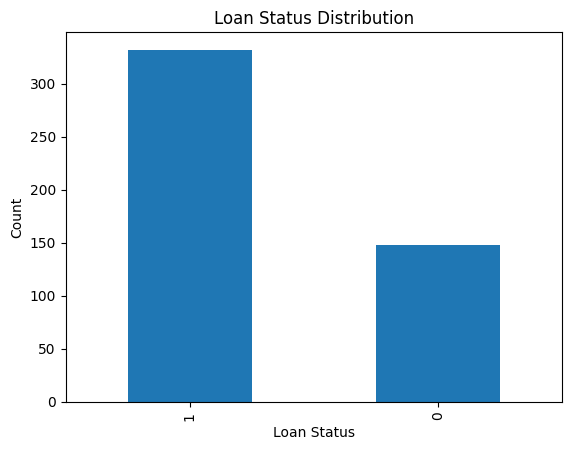

In [18]:
loan_dataset['Loan_Status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

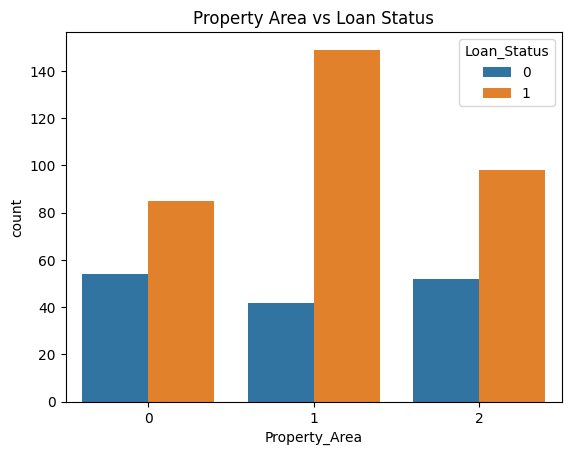

In [19]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_dataset)
plt.title("Property Area vs Loan Status")
plt.show()

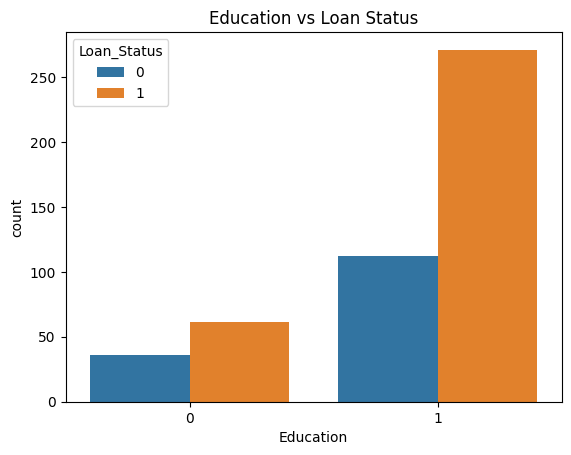

In [20]:
# education & Loan Status
sns.countplot(x='Education',hue='Loan_Status',data=loan_dataset)
plt.title("Education vs Loan Status")
plt.show()

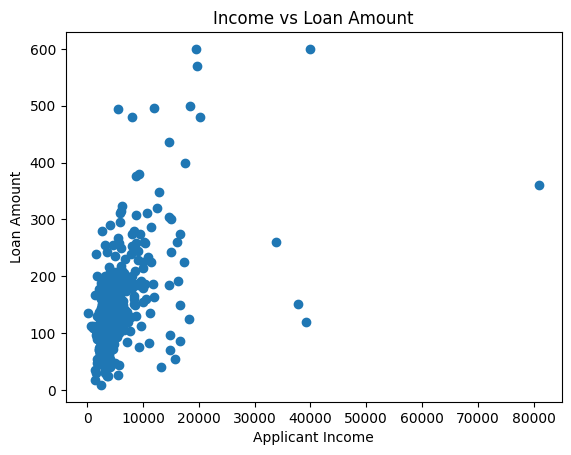

In [22]:
plt.scatter(loan_dataset['ApplicantIncome'], loan_dataset['LoanAmount'])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

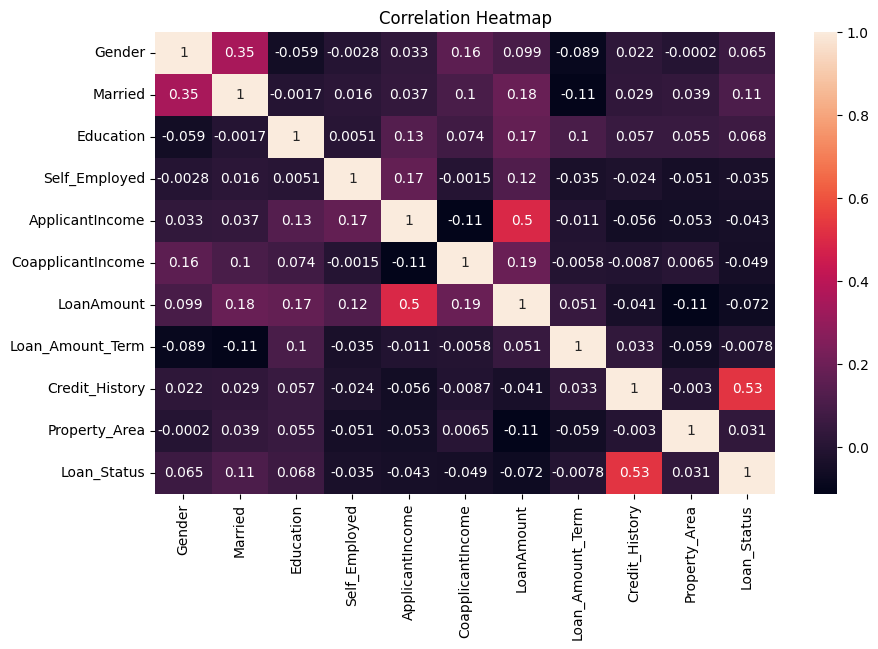

In [73]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(loan_dataset.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
# separating the data and label
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y = loan_dataset['Loan_Status']

In [25]:
print(X)
print(Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1          1          1              0             4583   
2         1        1          0          1              1             3000   
3         1        1          0          0              0             2583   
4         1        0          0          1              0             6000   
5         1        1          2          1              1             5417   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0             2900   
610       1        1          4          1              0             4106   
611       1        1          1          1              0             8072   
612       1        1          2          1              0             7583   
613       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

Train Test Split

In [26]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1,stratify=Y,random_state=2)

In [27]:
print(X.shape, X_train.shape, X_test.shape)

(480, 11) (432, 11) (48, 11)


Training the model:

Model Training (Multiple Models)

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [39]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "SVM": SVC(kernel='linear'),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

Model Evaluation

In [41]:
#training and Evaluate Models
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, Y_train)

    # Predictions
    Y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    # Print results
    print(f"{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("-" * 40)

SVM
Accuracy : 0.8333
Precision: 0.8378
Recall   : 0.9394
F1 Score : 0.8857
----------------------------------------
Logistic Regression
Accuracy : 0.8333
Precision: 0.8378
Recall   : 0.9394
F1 Score : 0.8857
----------------------------------------
Decision Tree
Accuracy : 0.7083
Precision: 0.7568
Recall   : 0.8485
F1 Score : 0.8000
----------------------------------------


In [47]:
#Convert Results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.833333   0.837838  0.939394  0.885714
1  Logistic Regression  0.833333   0.837838  0.939394  0.885714
2        Decision Tree  0.708333   0.756757  0.848485  0.800000


### Select best Model

In [48]:
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print("Best Model:", best_model_name)

Best Model: SVM


In [51]:
best_model = models[best_model_name]

Confusion Matrix:
 [[ 9  6]
 [ 2 31]]


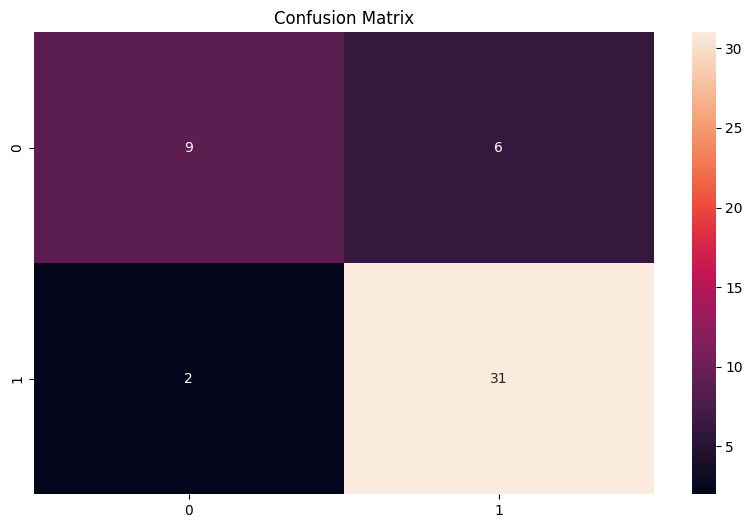

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions using best model
Y_pred = best_model.predict(X_test)

#Confusion Matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", conf_matrix)

#Display
plt.figure(figsize=(10,6))
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [54]:
#Classification Report
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(Y_test, Y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.60      0.69        15
           1       0.84      0.94      0.89        33

    accuracy                           0.83        48
   macro avg       0.83      0.77      0.79        48
weighted avg       0.83      0.83      0.83        48



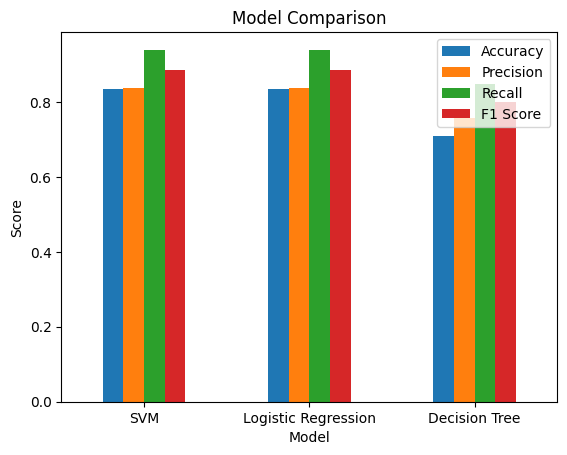

In [67]:
results_df.set_index("Model").plot(kind='bar')

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Making a predictive system

In [71]:
# Taking input from the user
Gender = int(input("Gender (Male=1, Female=0): "))
Married = int(input("Married (Yes=1, No=0): "))
Dependents = int(input("Dependents (0/1/2/3): "))
Education = int(input("Education (Graduate=1, Not Graduate=0): "))
Self_Employed = int(input("Self Employed (Yes=1, No=0): "))
ApplicantIncome = float(input("Applicant Income: "))
CoapplicantIncome = float(input("Coapplicant Income: "))
LoanAmount = float(input("Loan Amount: "))
Loan_Amount_Term = float(input("Loan Amount Term: "))
Credit_History = float(input("Credit History (1 or 0): "))
Property_Area = int(input("Property Area (Urban=2, Semiurban=1, Rural=0): "))

# Creating input list
input_data = [
    Gender, Married, Dependents, Education, Self_Employed,
    ApplicantIncome, CoapplicantIncome, LoanAmount,
    Loan_Amount_Term, Credit_History, Property_Area
]

# Converting to numpy array| coz Models internally work with NumPy arrays, Ensures correct format, Faster computation.
import numpy as np
input_data_as_numpy_array = np.asarray(input_data)

# Reshaping the array
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Making prediction
prediction = best_model.predict(input_data_reshaped)
#output result
if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Gender (Male=1, Female=0): 1
Married (Yes=1, No=0): 1
Dependents (0/1/2/3): 1
Education (Graduate=1, Not Graduate=0): 1
Self Employed (Yes=1, No=0): 0
Applicant Income: 200000
Coapplicant Income: 300000
Loan Amount: 2000000
Loan Amount Term: 36
Credit History (1 or 0): 1
Property Area (Urban=2, Semiurban=1, Rural=0): 2
Loan Not Approved


Each metric provides different insights. Accuracy shows overall performance, while precision, recall, and F1-score give class-level evaluation.
The confusion matrix helps analyze errors, and the correlation heatmap helps understand feature relationships.”


